### Import Libraries

In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, MinMaxScaler, StandardScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import FunctionTransformer, PowerTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import GridSearchCV

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm


from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

### Loading Dataset

In [2]:
df = pd.read_csv("Data\\rent.csv").iloc[:,1:]
df.sample(10)

,zone,room,bathroom,floor,t_floors,area,area_unit,area_type,furnishing,facing,power_backup,available_from,contact,rent
3899,South Delhi,2,2,1,4,1000.0,Sq.Ft.,Built-up Area,Furnished,North East,Available,Immediately,Contact Agent,"₹ 31,500"
4169,Dwarka,Studio,1,NaN,NaN,467.0,Sq.Ft.,Built-up Area,Furnished,NaN,NaN,Immediately,Contact Agent,"₹ 11,600"
2638,West Delhi,2,NaN,NaN,NaN,855.0,Sq.Ft.,Saleable Area,Semi-Furnished,NaN,Available,NaN,Contact Agent,"₹ 18,000"
4582,South Delhi,3,2,NaN,NaN,1378.0,Sq.Ft.,Built-up Area,Semi-Furnished,NaN,NaN,Immediately,Contact Agent,Price on Request
78,South Delhi,3,3,3rd,5th floor,1500.0,Sq.Ft.,Built-up Area,Furnished,South,Available,Immediately,Contact Agent,"₹ 75,000"
1610,East Delhi,2,NaN,NaN,NaN,855.0,Sq.Ft.,Built-up Area,Semi-Furnished,NaN,NaN,Immediately,Contact Agent,"₹ 19,200"
999,South Delhi,3,3,3,4,1800.0,Sq.Ft.,Built-up Area,Furnished,East,No Back-up,Immediately,Contact Agent,₹ 1 L
748,East Delhi,2,1,NaN,NaN,1219.0,Sq.Ft.,Built-up Area,Furnished,NaN,NaN,Immediately,Contact Agent,"₹ 20,360"
2349,East Delhi,2,NaN,NaN,NaN,740.0,Sq.Ft.,Built-up Area,Furnished,NaN,NaN,Immediately,Contact Agent,"₹ 26,700"
2243,Dwarka,1 Rk,1,3,10,385.0,Sq.Ft.,Built-up Area,Semi-Furnished,NaN,NaN,Immediately,Contact Agent,Price on Request


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5488 entries, 0 to 5487
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   zone            5293 non-null   object 
 1   room            5467 non-null   object 
 2   bathroom        4292 non-null   object 
 3   floor           2530 non-null   object 
 4   t_floors        2290 non-null   object 
 5   area            5488 non-null   float64
 6   area_unit       5488 non-null   object 
 7   area_type       5488 non-null   object 
 8   furnishing      5488 non-null   object 
 9   facing          2296 non-null   object 
 10  power_backup    1986 non-null   object 
 11  available_from  5255 non-null   object 
 12  contact         5488 non-null   object 
 13  rent            5488 non-null   object 
dtypes: float64(1), object(13)
memory usage: 600.4+ KB


### Data Cleaning

In [4]:
# Dropping rows with no price
df = df[~(df['rent'] == 'Price on Request')]

In [5]:
# Checking for null values
df.isnull().sum()

zone               183
room                21
bathroom           981
floor             2410
t_floors          2597
area                 0
area_unit            0
area_type            0
furnishing           0
facing            2604
power_backup      2896
available_from     203
contact              0
rent                 0
dtype: int64

In [6]:
# Dropping columns with more than 50% missing values
df = df.drop(columns = ['floor', 't_floors', 'facing'])

In [7]:
df['zone'].value_counts()

zone
South Delhi      1824
East Delhi       1391
Dwarka            605
West Delhi        467
North Delhi       177
Central Delhi      73
Name: count, dtype: int64

In [8]:
# Dropping rows with missing values in zones as they can't be imputed
df = df[~(df['zone'].isnull())]

In [9]:
df['power_backup'].value_counts()

power_backup
Available     1003
No Back-up     758
Name: count, dtype: int64

In [10]:
# Imputing missing values in 'power_backup' with 'Not Mentioned'
df['power_backup'] = df['power_backup'].fillna('Not Mentioned')

In [11]:
df['room'].value_counts(), df['bathroom'].value_counts()

(room
 2         1729
 3         1155
 1          876
 4          270
 2.5        137
 1.5        106
 1 Rk        99
 3.5         67
 Studio      63
 5           12
 6+           3
 Name: count, dtype: int64,
 bathroom
 2     1519
 1     1149
 3      706
 4      200
 5       27
 6+       1
 6        1
 Name: count, dtype: int64)

In [12]:
# Dropping rows with studio and 1 RK apartments
df = df[~((df['room'] == '1 Rk') | (df['room'] == 'Studio'))]

In [13]:
# Dropping rows with missing values in both 'room' and 'bathroom' columns
df = df[~((df['room'].isnull()) & (df['bathroom'].isnull()))]

In [14]:
df['available_from'].value_counts()

available_from
Immediately    4152
Later            36
Name: count, dtype: int64

In [15]:
# Imputing missing values in 'available_from' with 'Not Mentioned'
df['available_from'] = df['available_from'].fillna('Not Mentioned')

In [16]:
# Converting the 'room' and 'bathroom' columns into numeric columns
df['room'] = df['room'].str.split('+').str[0].astype('float64')
df['bathroom'] = df['bathroom'].str.split('+').str[0].astype('float64')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4373 entries, 0 to 5487
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   zone            4373 non-null   object 
 1   room            4355 non-null   float64
 2   bathroom        3461 non-null   float64
 3   area            4373 non-null   float64
 4   area_unit       4373 non-null   object 
 5   area_type       4373 non-null   object 
 6   furnishing      4373 non-null   object 
 7   power_backup    4373 non-null   object 
 8   available_from  4373 non-null   object 
 9   contact         4373 non-null   object 
 10  rent            4373 non-null   object 
dtypes: float64(3), object(8)
memory usage: 410.0+ KB


In [18]:
df['area_unit'].value_counts()

area_unit
Sq.Ft.    4207
Sq.Yd.     165
Acre         1
Name: count, dtype: int64

In [19]:
df[df['area_unit'] == 'Acre']

,zone,room,bathroom,area,area_unit,area_type,furnishing,power_backup,available_from,contact,rent
5104,South Delhi,3.0,3.0,2000.0,Acre,Built-up Area,Semi-Furnished,No Back-up,Immediately,Contact Agent,₹ 1.6 L


In [20]:
# Coverting areas in 'Sq.Yd.' to 'Sq.Ft.' for uniformity
df.loc[df["area_unit"] == "Sq.Yd.", "area"] *= 9

In [21]:
df['area_type'].value_counts()

area_type
Built-up Area    4176
Carpet Area       123
Saleable Area      71
Plot Area           3
Name: count, dtype: int64

In [22]:
df = df[df['area_type'] == 'Built-up Area']

In [23]:
# Dropping columns that are not neccessary anymore
df = df.drop(columns = ['area_unit', 'area_type'])

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4176 entries, 0 to 5487
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   zone            4176 non-null   object 
 1   room            4174 non-null   float64
 2   bathroom        3274 non-null   float64
 3   area            4176 non-null   float64
 4   furnishing      4176 non-null   object 
 5   power_backup    4176 non-null   object 
 6   available_from  4176 non-null   object 
 7   contact         4176 non-null   object 
 8   rent            4176 non-null   object 
dtypes: float64(3), object(6)
memory usage: 326.2+ KB


In [25]:
# Coverting the 'rent' column into numeric
df["rent"] = df["rent"].str.split(" ", n = 1).str[1].apply(lambda x: 
                                                           float(x.split(" ")[0])*100000 if x.endswith("L") 
                                                           else float("".join(x.split(","))))

In [26]:
df.describe()

,room,bathroom,area,rent
count,4174.000000,3274.000000,4176.000000,4176.000000
mean,2.212027,2.041234,1174.266044,47179.027299
std,0.862227,0.896310,945.932402,64039.836320
min,1.000000,1.000000,100.000000,8000.000000
25%,2.000000,1.000000,650.000000,18700.000000
50%,2.000000,2.000000,950.000000,28000.000000
75%,3.000000,3.000000,1452.750000,46000.000000
max,6.000000,6.000000,22572.000000,1000000.000000


In [27]:
# Dropping rows with unusual data
df = df[~((df["area"] < 400) & (df["room"] > 1))]
df = df[~(df['area'] < 200)]

### EDA and Feature Engineering

#### Categorical Columns

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4134 entries, 0 to 5487
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   zone            4134 non-null   object 
 1   room            4132 non-null   float64
 2   bathroom        3254 non-null   float64
 3   area            4134 non-null   float64
 4   furnishing      4134 non-null   object 
 5   power_backup    4134 non-null   object 
 6   available_from  4134 non-null   object 
 7   contact         4134 non-null   object 
 8   rent            4134 non-null   float64
dtypes: float64(4), object(5)
memory usage: 323.0+ KB


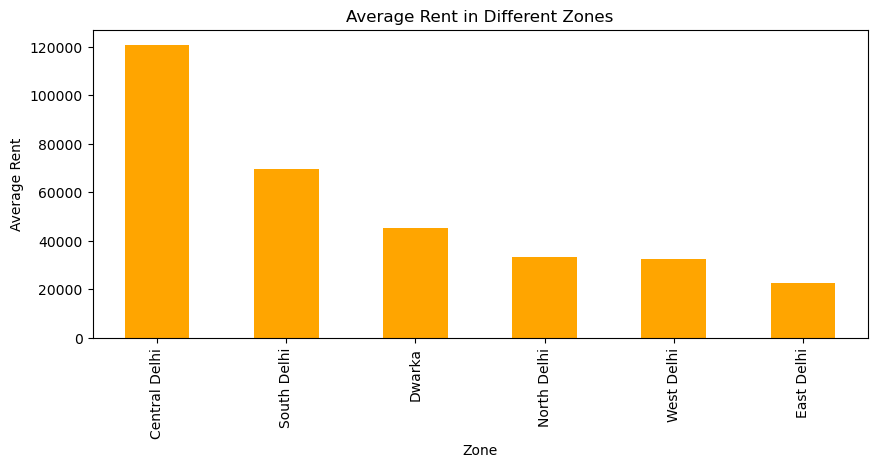

In [29]:
df.groupby('zone')['rent'].mean().sort_values(ascending = False).plot.bar(figsize = (10, 4), color = 'orange')
plt.title('Average Rent in Different Zones')
plt.xlabel('Zone')
plt.ylabel('Average Rent')
plt.show()

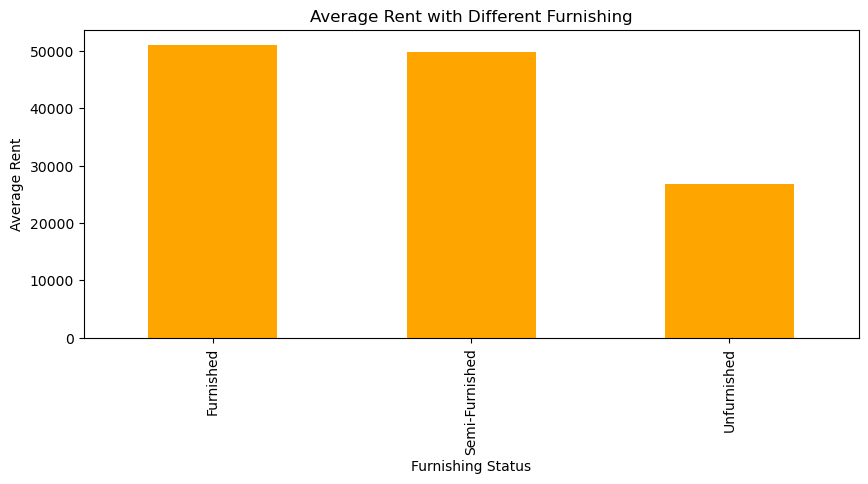

In [31]:
df.groupby('furnishing')['rent'].mean().sort_values(ascending = False).plot.bar(figsize = (10, 4), color = 'orange', )
plt.title('Average Rent with Different Furnishing')
plt.xlabel('Furnishing Status')
plt.ylabel('Average Rent')
plt.show()

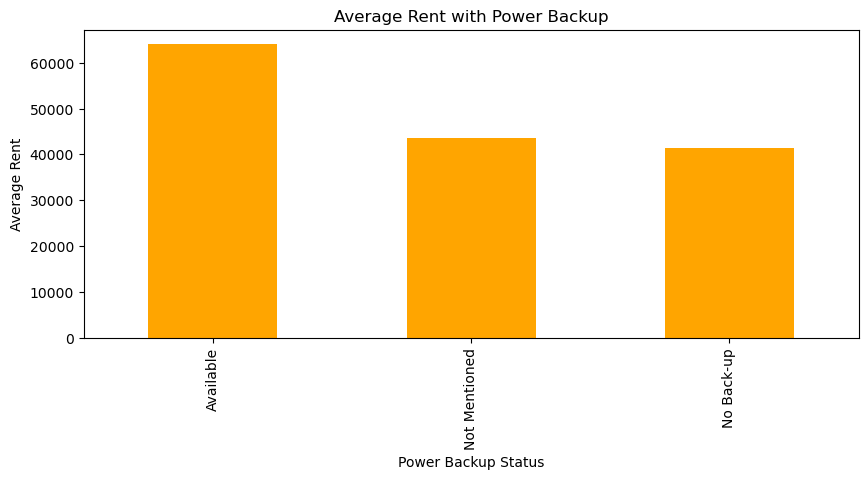

In [32]:
df.groupby('power_backup')['rent'].mean().sort_values(ascending = False).plot.bar(figsize = (10, 4), color = 'orange')
plt.title('Average Rent with Power Backup')
plt.xlabel('Power Backup Status')
plt.ylabel('Average Rent')
plt.show()

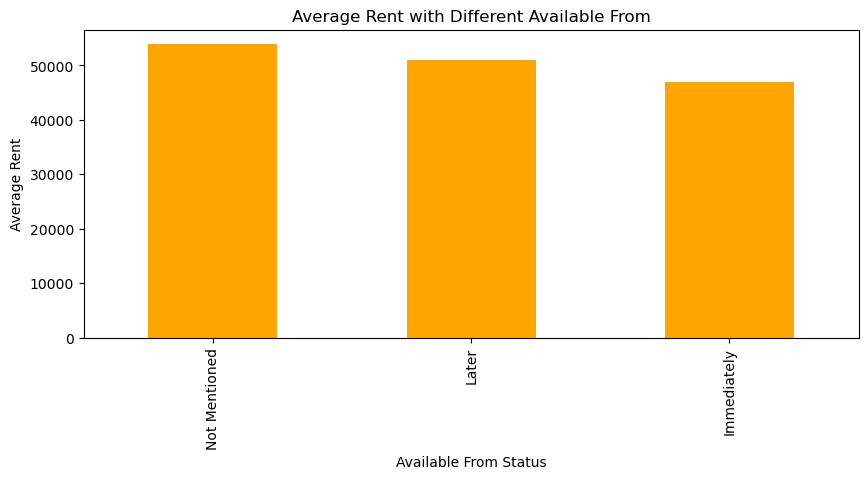

In [33]:
df.groupby('available_from')['rent'].mean().sort_values(ascending = False).plot.bar(figsize = (10, 4), color = 'orange')
plt.title('Average Rent with Different Available From')
plt.xlabel('Available From Status')
plt.ylabel('Average Rent')
plt.show()

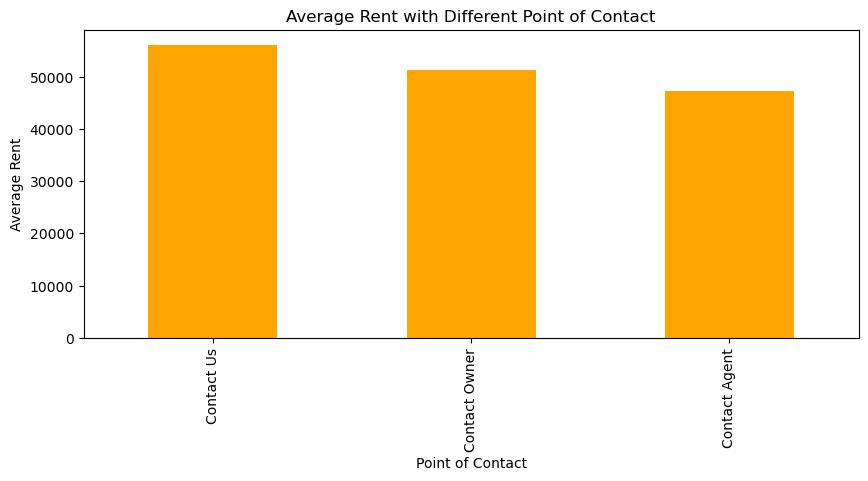

In [34]:
df.groupby('contact')['rent'].mean().sort_values(ascending = False).plot.bar(figsize = (10, 4), color = 'orange')
plt.title('Average Rent with Different Point of Contact')
plt.xlabel('Point of Contact')
plt.ylabel('Average Rent')
plt.show()

#### Numerical Columns

In [35]:
df.describe()

,room,bathroom,area,rent
count,4132.000000,3254.000000,4134.000000,4134.000000
mean,2.216844,2.043639,1184.745283,47318.243590
std,0.863640,0.897413,944.941294,64311.831541
min,1.000000,1.000000,200.000000,8000.000000
25%,2.000000,1.000000,654.000000,18700.000000
50%,2.000000,2.000000,952.500000,28000.000000
75%,3.000000,3.000000,1483.250000,46500.000000
max,6.000000,6.000000,22572.000000,1000000.000000


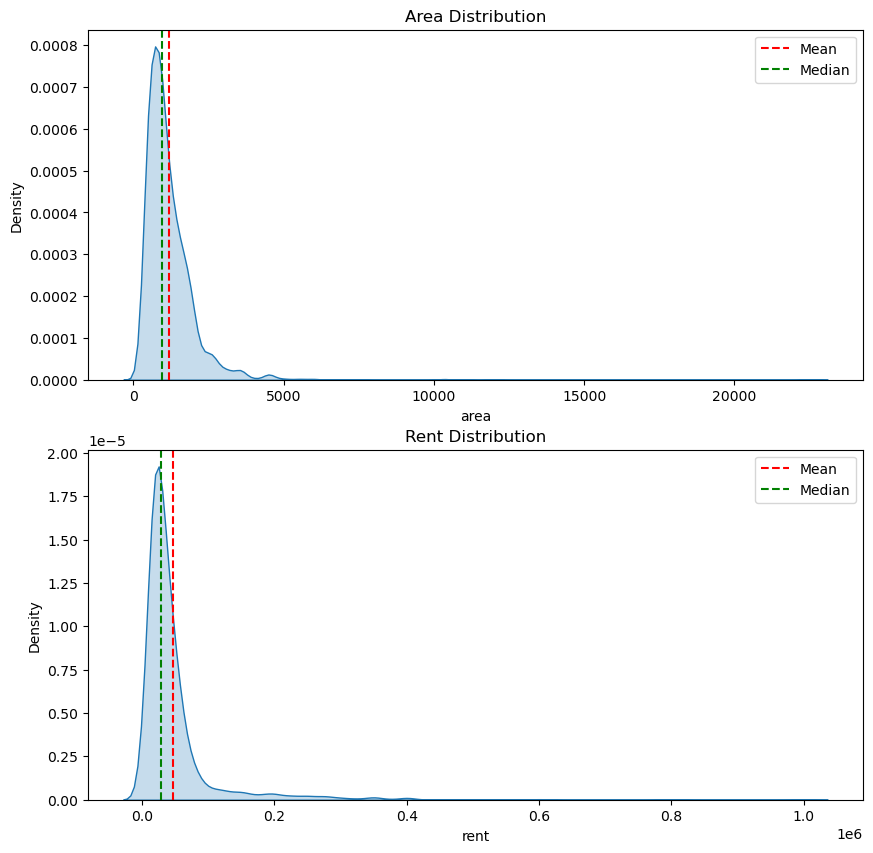

In [36]:
fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize = (10,10))

sns.kdeplot(df['area'], fill = True, ax = ax[0])
ax[0].set_title('Area Distribution')
ax[0].axvline(df['area'].mean(), color = 'red', linestyle = '--', label = 'Mean')
ax[0].axvline(df['area'].median(), color = 'green', linestyle = '--', label = 'Median')

sns.kdeplot((df['rent']), fill = True, ax = ax[1])
ax[1].set_title('Rent Distribution')
ax[1].axvline(df['rent'].mean(), color = 'red', linestyle = '--', label = 'Mean')
ax[1].axvline(df['rent'].median(), color = 'green', linestyle = '--', label = 'Median')

ax[0].legend()
ax[1].legend()
plt.show()

In [37]:
print(f"Area Skewness: {df['area'].skew()}")
print(f"Rent Skewness: {df['rent'].skew()}")

Area Skewness: 8.036457909081669
Rent Skewness: 5.19363368428153


#### Multivariate Analysis

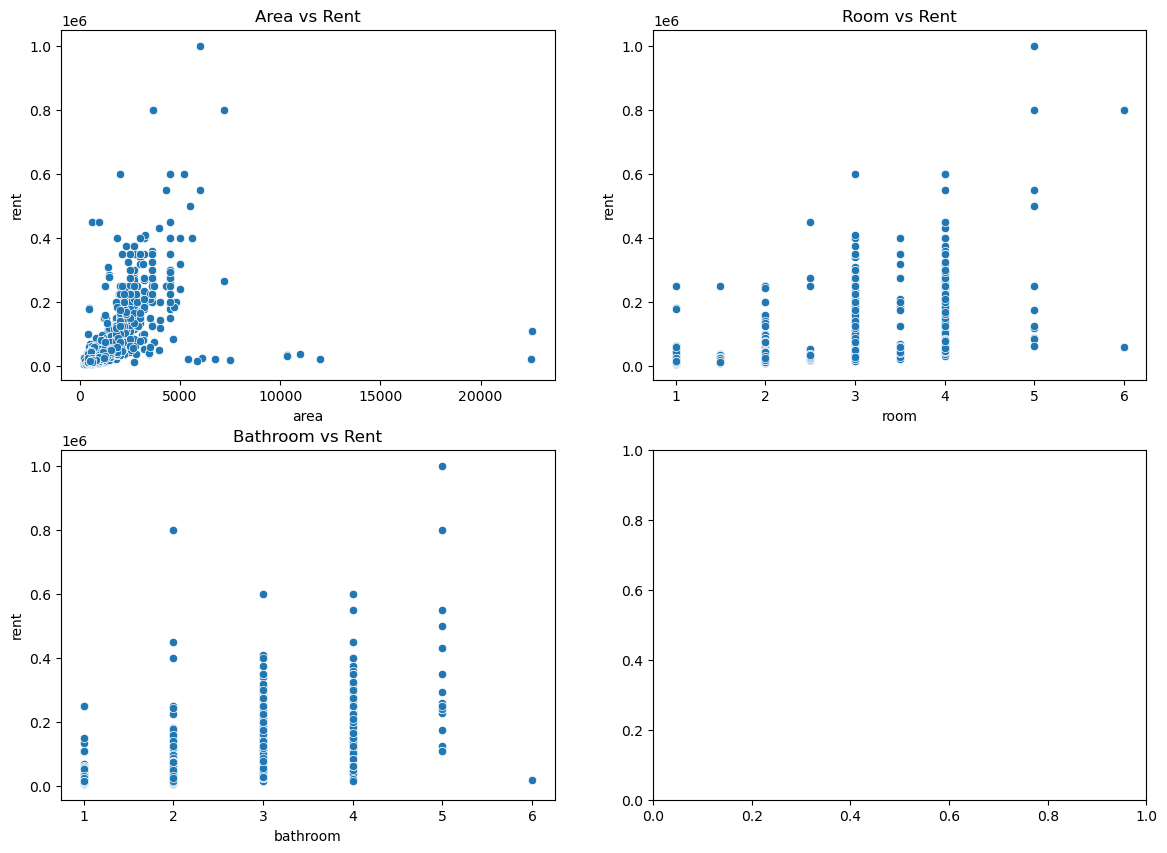

In [38]:
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (14, 10))

sns.scatterplot(x = 'area', y = 'rent', data = df, ax = ax[0, 0])
ax[0, 0].set_title('Area vs Rent')

sns.scatterplot(x = 'room', y = 'rent', data = df, ax = ax[0, 1])
ax[0, 1].set_title('Room vs Rent')

sns.scatterplot(x = 'bathroom', y = 'rent', data = df, ax = ax[1, 0])
ax[1, 0].set_title('Bathroom vs Rent')

plt.show()

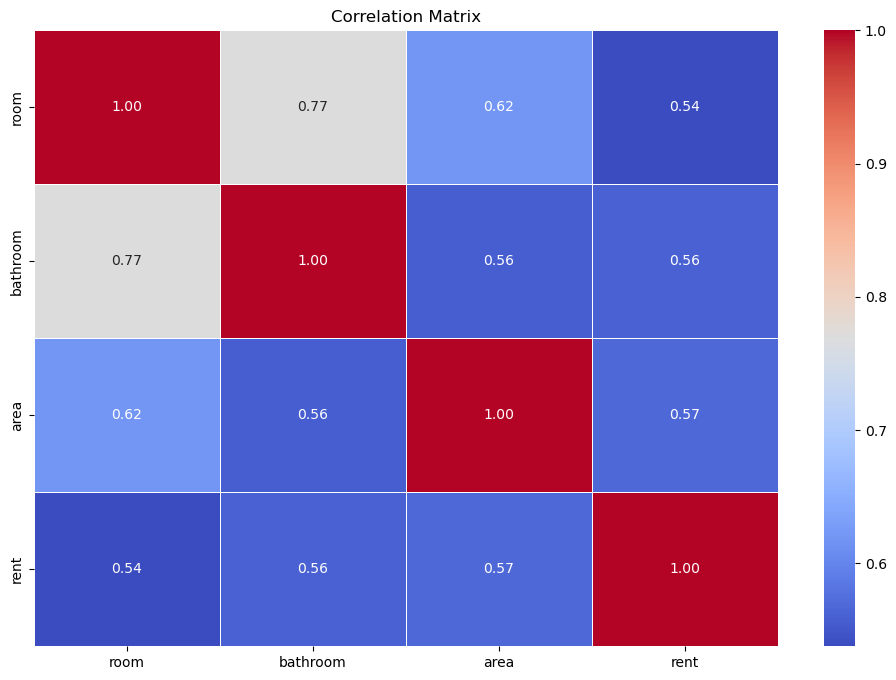

In [39]:
corr_matrix = df.corr(numeric_only = True)

plt.figure(figsize = (12, 8))
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm', fmt = '.2f', linewidths = 0.5)
plt.title('Correlation Matrix')
plt.show()

Tranfrorming area and rent column


In [40]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='box-cox', standardize=True)

df['rent'] = pt.fit_transform(pd.DataFrame(df['rent']))
df['area'] = pt.fit_transform(pd.DataFrame(df['area']))

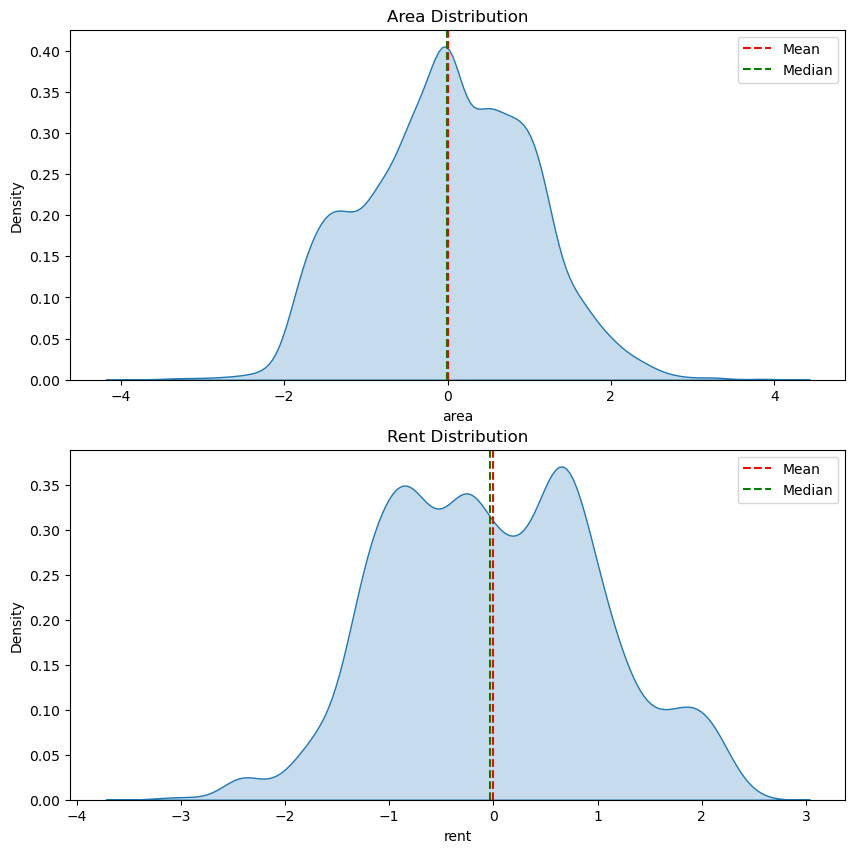

In [41]:
fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize = (10,10))

sns.kdeplot(df['area'], fill = True, ax = ax[0])
ax[0].set_title('Area Distribution')
ax[0].axvline(df['area'].mean(), color = 'red', linestyle = '--', label = 'Mean')
ax[0].axvline(df['area'].median(), color = 'green', linestyle = '--', label = 'Median')

sns.kdeplot((df['rent']), fill = True, ax = ax[1])
ax[1].set_title('Rent Distribution')
ax[1].axvline(df['rent'].mean(), color = 'red', linestyle = '--', label = 'Mean')
ax[1].axvline(df['rent'].median(), color = 'green', linestyle = '--', label = 'Median')

ax[0].legend()
ax[1].legend()
plt.show()

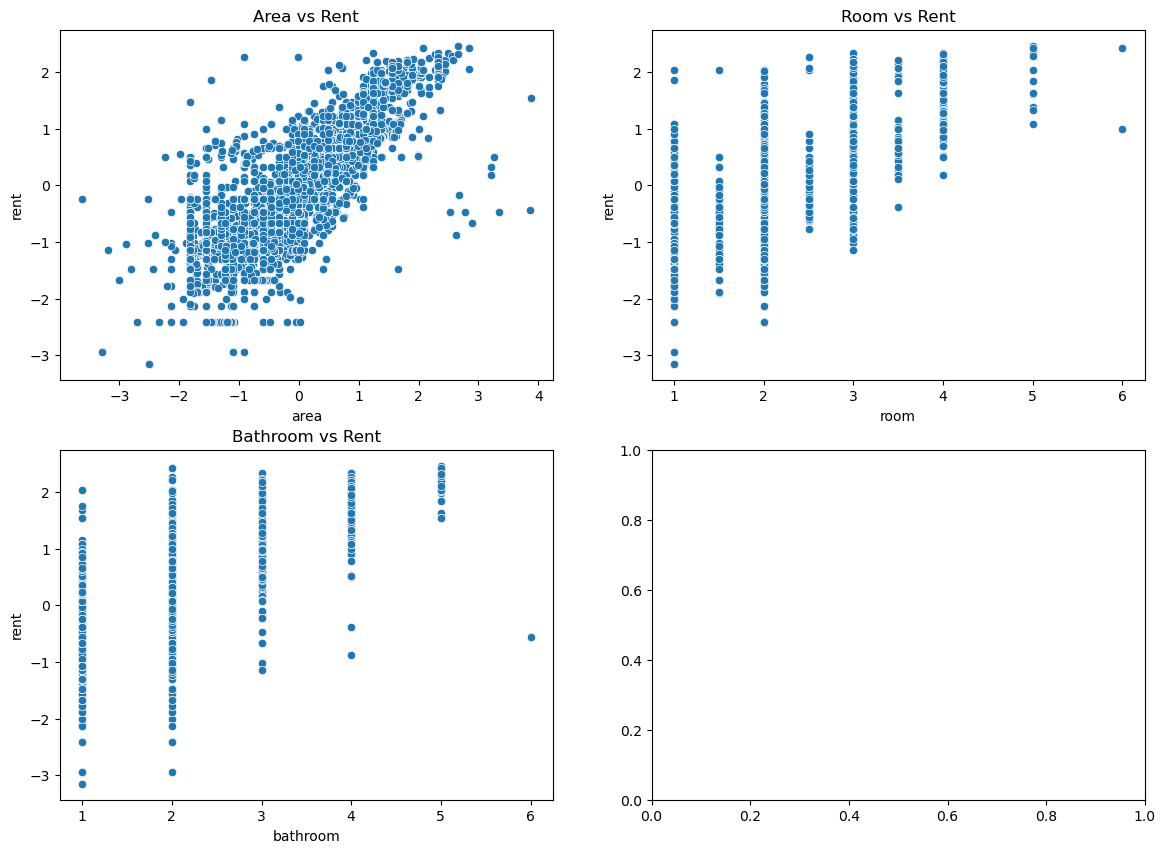

In [42]:
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (14, 10))

sns.scatterplot(x = 'area', y = 'rent', data = df, ax = ax[0, 0])
ax[0, 0].set_title('Area vs Rent')

sns.scatterplot(x = 'room', y = 'rent', data = df, ax = ax[0, 1])
ax[0, 1].set_title('Room vs Rent')

sns.scatterplot(x = 'bathroom', y = 'rent', data = df, ax = ax[1, 0])
ax[1, 0].set_title('Bathroom vs Rent')

plt.show()

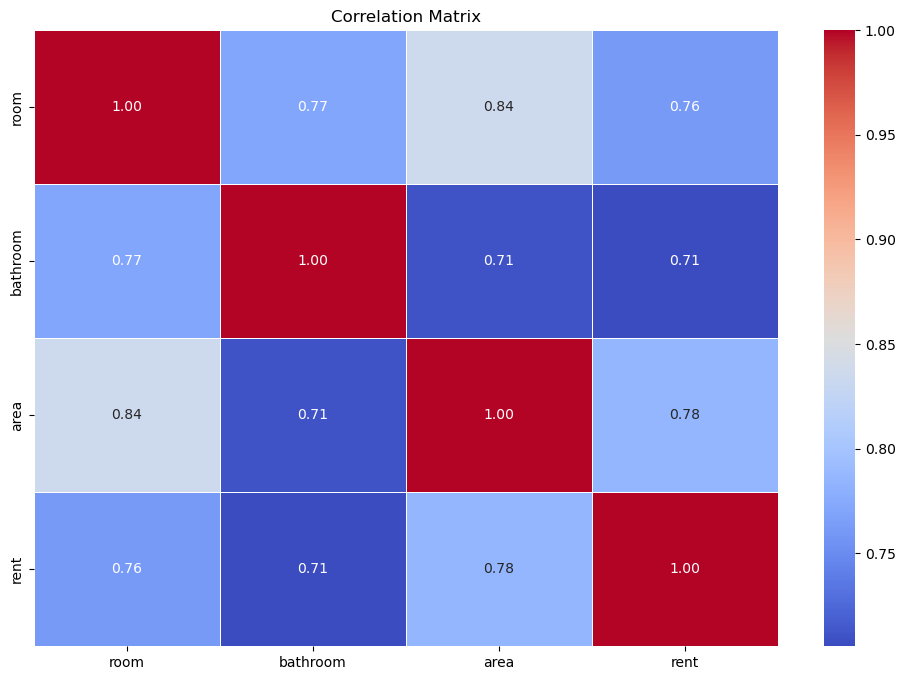

In [43]:
corr_matrix = df.corr(numeric_only = True)

plt.figure(figsize = (12, 8))
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm', fmt = '.2f', linewidths = 0.5)
plt.title('Correlation Matrix')
plt.show()

#### Outlier Detection and Removal

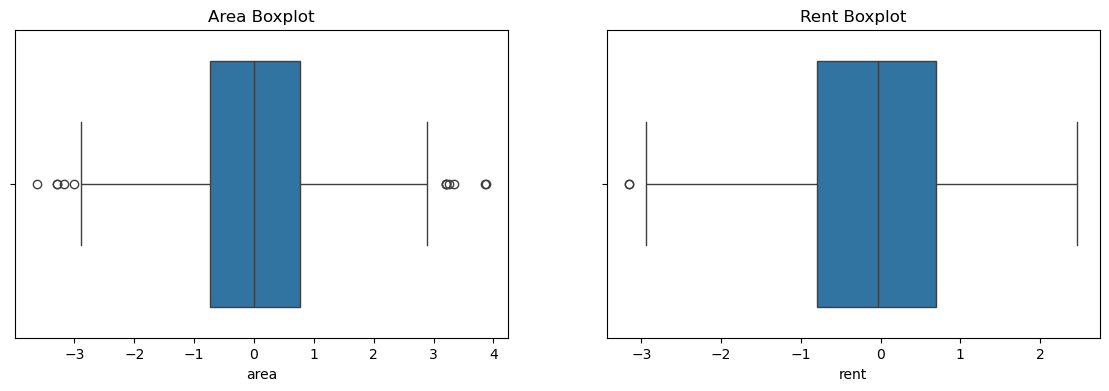

In [44]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (14,4))

sns.boxplot(x = df['area'], ax = ax[0])
ax[0].set_title('Area Boxplot')

sns.boxplot(x = df['rent'], ax = ax[1])
ax[1].set_title('Rent Boxplot')

plt.show()

In [45]:
# removing outliers in 'rent' column using Z-score method
# df = df[~(df['rent'] - df['rent'].mean() > 3 * df['rent'].std())]

#### Check for Multicollinearity

In [47]:
X = df[['room', 'bathroom', 'area']].dropna()

X = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

    feature        VIF
0     const  23.469288
1      room   4.392053
2  bathroom   2.534797
3      area   3.608250


In [48]:
df['bathroom_to_room_ratio'] = df['bathroom'] / df['room']

In [388]:
# Creating a new feature 'total_room' by adding 'room' and 'bathroom'
df['total_room'] = df['room'] + df['bathroom']

In [50]:
X_new = df[['bathroom_to_room_ratio', 'area']].dropna()

X_new = sm.add_constant(X_new)

vif_data = pd.DataFrame()
vif_data["feature"] = X_new.columns
vif_data["VIF"] = [variance_inflation_factor(X_new.values, i) for i in range(X_new.shape[1])]
print(vif_data)

                  feature        VIF
0                   const  10.072368
1  bathroom_to_room_ratio   1.039705
2                    area   1.039705


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4134 entries, 0 to 5487
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   zone                    4134 non-null   object 
 1   room                    4132 non-null   float64
 2   bathroom                3254 non-null   float64
 3   area                    4134 non-null   float64
 4   furnishing              4134 non-null   object 
 5   power_backup            4134 non-null   object 
 6   available_from          4134 non-null   object 
 7   contact                 4134 non-null   object 
 8   rent                    4134 non-null   float64
 9   bathroom_to_room_ratio  3252 non-null   float64
dtypes: float64(5), object(5)
memory usage: 355.3+ KB


In [55]:
df.dropna(subset = ['room'], inplace = True)

### Train-Test Split

In [56]:
X = df.drop(columns = ['rent'])
y = np.log(df['rent'])

c:\Users\PARVEZ KHAN\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, df['rent'], test_size = 0.2, random_state = 44)

Imputing 'bathroom' column by regression with 'room' and 'area' as regressors

In [59]:
X1_train = X_train.loc[~(X_train['bathroom'].isnull()), ['room', 'area']]
y1_train = X_train.loc[~(X_train['bathroom'].isnull()), ['bathroom']]

In [61]:
lr1 = LinearRegression()
lr1.fit(X1_train, y1_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [62]:
bathroom_pred_train = lr1.predict(X_train.loc[X_train['bathroom'].isnull(), ['room', 'area']])
bathroom_pred_test = lr1.predict(X_test.loc[X_test['bathroom'].isnull(), ['room', 'area']])
    
X_train.loc[X_train['bathroom'].isnull(), 'bathroom'] = bathroom_pred_train.round()
X_test.loc[X_test['bathroom'].isnull(), 'bathroom'] = bathroom_pred_test.round()

In [64]:
X_train['bathroom_to_room_ratio'] = X_train['bathroom'] / X_train['room']
X_test['bathroom_to_room_ratio'] = X_test['bathroom'] / X_test['room']

In [66]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3305 entries, 203 to 4657
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   zone                    3305 non-null   object 
 1   room                    3305 non-null   float64
 2   bathroom                3305 non-null   float64
 3   area                    3305 non-null   float64
 4   furnishing              3305 non-null   object 
 5   power_backup            3305 non-null   object 
 6   available_from          3305 non-null   object 
 7   contact                 3305 non-null   object 
 8   bathroom_to_room_ratio  3305 non-null   float64
dtypes: float64(4), object(5)
memory usage: 258.2+ KB


In [67]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 827 entries, 1039 to 1854
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   zone                    827 non-null    object 
 1   room                    827 non-null    float64
 2   bathroom                827 non-null    float64
 3   area                    827 non-null    float64
 4   furnishing              827 non-null    object 
 5   power_backup            827 non-null    object 
 6   available_from          827 non-null    object 
 7   contact                 827 non-null    object 
 8   bathroom_to_room_ratio  827 non-null    float64
dtypes: float64(4), object(5)
memory usage: 64.6+ KB


### Model Fitting

In [72]:
trf = ColumnTransformer([
    # ('area', Pipeline([
    #     ('log', FunctionTransformer(np.log)),
    #     ('scale', MinMaxScaler())
    # ]), ['area']),

    ('room', MinMaxScaler(), ['area', 'room', 'bathroom_to_room_ratio']),
    
    ('ohe', OneHotEncoder(sparse_output = False, drop = 'first', handle_unknown = 'ignore'), ['zone', 'contact', 'available_from']),
    
    ('oe', OrdinalEncoder(categories = [['Unfurnished', 'Semi-Furnished', 'Furnished'],
                                       ['No Back-up', 'Not Mentioned', 'Available'],]), ['furnishing', 'power_backup'])
], remainder='passthrough')

#### Linear Regression

In [73]:
lr = LinearRegression()

In [74]:
pipe = Pipeline([
    ('trf', trf),
    ('model', lr),
])

In [75]:
pipe.fit(X_train, y_train)

,steps,"[('trf', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('room', ...), ('ohe', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [76]:
y_pred = pipe.predict(X_test)
y_pred_train = pipe.predict(X_train)

mae = mean_absolute_error(y_test, y_pred)
mse = root_mean_squared_error(y_test, y_pred)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred)
adjusted_r2 = 1 - (1 - r2_test) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)

print(f"MAE: {mae}")
print(f"RMSE: {mse}\n")
print(f"R2 Score (Train): {r2_train}")
print(f"R2 Score (Test): {r2_test}\n")
print(f"Adjusted R2 Score: {adjusted_r2}")

MAE: 0.38482290752807324
RMSE: 0.5004905440752857

R2 Score (Train): 0.755028961617657
R2 Score (Test): 0.7682925175057391

Adjusted R2 Score: 0.765740048298336


### Linear Regression Assumption Check

#### Normality of Residuals

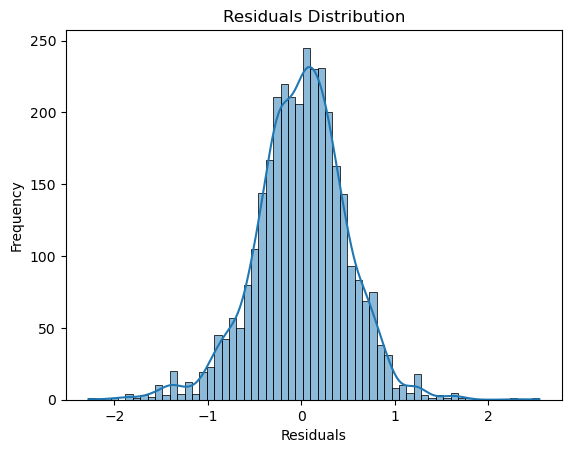

Residuals Skewness: -0.21093757586976733
Mean of Residuals: -4.681412426982204e-16


In [77]:
residuals = y_train - y_pred_train

sns.histplot(residuals, kde = True)
plt.title('Residuals Distribution')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

print(f"Residuals Skewness: {residuals.skew()}")
print(f"Mean of Residuals: {residuals.mean()}")

#### Homoscedasticity

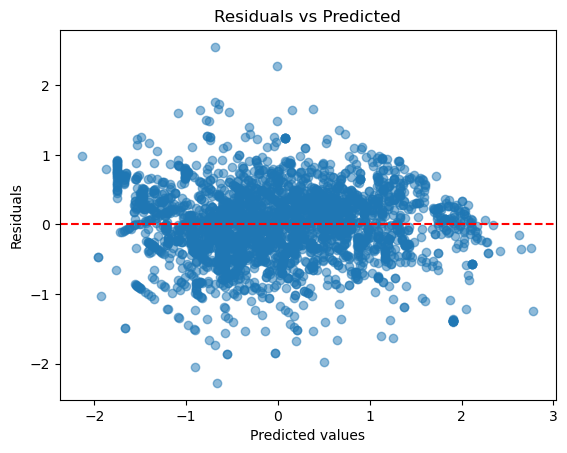

In [78]:
plt.scatter(y_pred_train, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

The variance of residuals doesn't change with the predictions implying homoscedasticity

#### Independence of Residuals

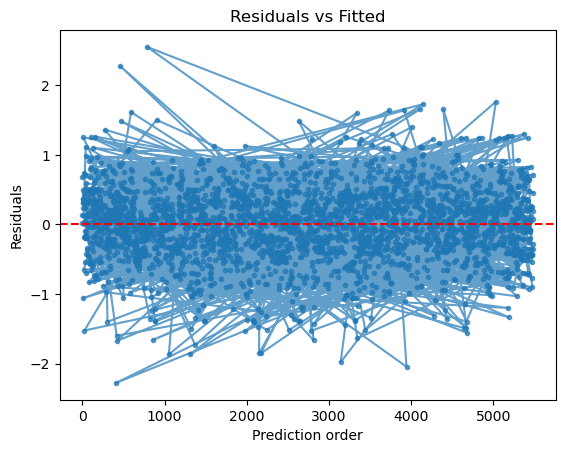

In [79]:
plt.plot(residuals, marker='.', linestyle='-', alpha=0.7,)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Prediction order")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

In [80]:
from statsmodels.stats.stattools import durbin_watson
print("Durbin-Watson statistic:", durbin_watson(residuals))

Durbin-Watson statistic: 1.9702856001450129


DW Statistic = 1.97 implying no autocorrelation

### Decision Tree

In [93]:
dt = DecisionTreeRegressor(min_samples_split = 25)

In [94]:
pipe = Pipeline([
    ('trf', trf),
    ('model', dt),
])

In [95]:
pipe.fit(X_train, y_train)

,steps,"[('trf', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('room', ...), ('ohe', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [96]:
y_pred = pipe.predict(X_test)
y_pred_train = pipe.predict(X_train)

mae = mean_absolute_error(y_test, y_pred)
mse = root_mean_squared_error(y_test, y_pred)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred)
adjusted_r2 = 1 - (1 - r2_test) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)

print(f"MAE: {mae}")
print(f"RMSE: {mse}\n")
print(f"R2 Score (Train): {r2_train}")
print(f"R2 Score (Test): {r2_test}\n")
print(f"Adjusted R2 Score: {adjusted_r2}")

MAE: 0.2953604996845939
RMSE: 0.45023964844984005

R2 Score (Train): 0.8810920622381283
R2 Score (Test): 0.8124851017091363

Adjusted R2 Score: 0.8104194541147449


### Random Forest

In [141]:
rf_grid_pipeline = Pipeline([
    ('trf', trf),
    ('model', RandomForestRegressor(random_state=44))
])

param_grid = {
    'model__n_estimators': [100, 200, 300, 400, 500],
    'model__min_samples_split': [5, 10, 20, 30],
    'model__max_features': ['sqrt', 'log2', 1.0]
}

grid_search = GridSearchCV(
    estimator=rf_grid_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
y_pred_grid = best_rf.predict(X_test)

print("Best parameters:", grid_search.best_params_)
print("Best CV R²:", grid_search.best_score_)
print("Test R²:", r2_score(y_test, y_pred_grid))

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best parameters: {'model__max_features': 'sqrt', 'model__min_samples_split': 5, 'model__n_estimators': 500}
Best CV R²: 0.8399296176547676
Test R²: 0.8556009249569263


In [150]:
rf = RandomForestRegressor(min_samples_split = 8, n_estimators = 400, max_features = 'sqrt')

In [151]:
pipe = Pipeline([
    ('trf1', trf),
    ('model', rf),
])

In [152]:
pipe.fit(X_train, y_train)

,steps,"[('trf1', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('room', ...), ('ohe', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [153]:
y_pred = pipe.predict(X_test)
y_pred_train = pipe.predict(X_train)

mae = mean_absolute_error(y_test, y_pred)
mse = root_mean_squared_error(y_test, y_pred)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred)
adjusted_r2 = 1 - (1 - r2_test) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)

print(f"MAE: {mae}")
print(f"RMSE: {mse}\n")
print(f"R2 Score (Train): {r2_train}")
print(f"R2 Score (Test): {r2_test}\n")
print(f"Adjusted R2 Score: {adjusted_r2}")

MAE: 0.25293144316790667
RMSE: 0.3941867881666863

R2 Score (Train): 0.9203100202070083
R2 Score (Test): 0.8562683426112097

Adjusted R2 Score: 0.8546850073400969
